In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import pickle as pkl

from mist.utils.plot_utils import *
import mist.utils as utils

from rdkit.Chem import MolFromSmiles
from rdkit.Chem.Draw import ShowMol
FS = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 
                                   'Bitstream Vera Sans', 'sans-serif']
plt.rcParams.update({'font.size': FS})

In [140]:
canopus_data = utils.parse_spectra_mgf('../data/paired_spectra/canopus_sample.mgf')
canopus_data[0][1][0][1].shape

2it [00:00, 2300.77it/s]


(182, 2)

In [141]:
with open('../data/neims/mist/df_neims_canopus_3_8_18.pkl', 'rb') as file:
    canopus_neims_data = pkl.load(file)
canopus_neims_data = canopus_neims_data[canopus_neims_data['SMILES'] == 'CCC(=O)CCCCCC1NC(=O)C2CCCCN2C(=O)C(Cc2ccccc2)NC(=O)C(C)NC1=O']['spec']
canopus_neims_data = canopus_neims_data.values[0].astype(np.int64)
canopus_neims_data.shape

(270, 2)

<BarContainer object of 270 artists>

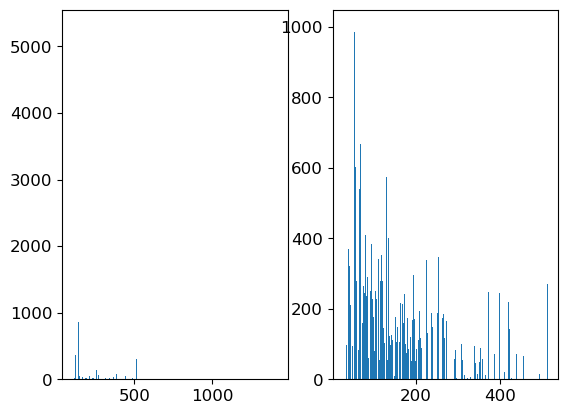

In [142]:
canopus_spec = canopus_data[0][1][0][1]
locs, ints = canopus_spec[:,0], canopus_spec[:,1]
fig, (ax1, ax2) =  plt.subplots(1,2)
ax1.bar(locs, ints)

locs_neims, ints_neims = canopus_neims_data[:,0], canopus_neims_data[:,1]
ax2.bar(locs_neims, ints_neims)

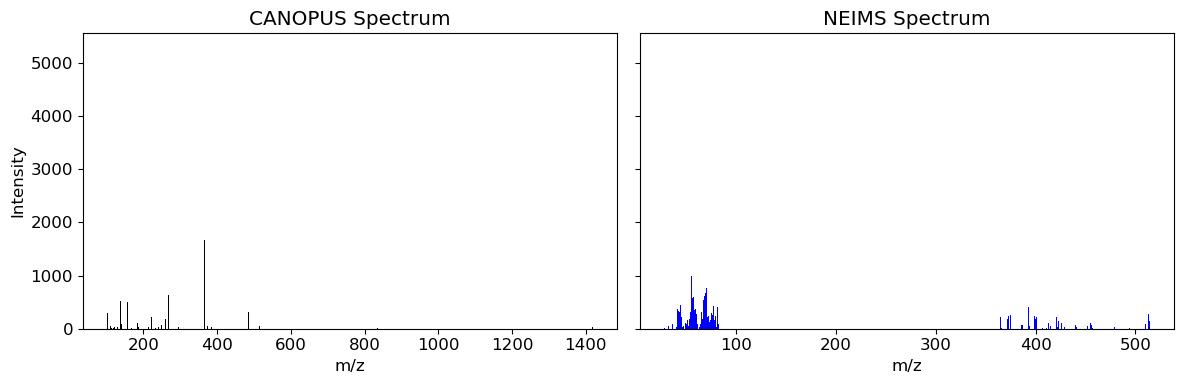

In [143]:
# Unpack CANOPUS mass spectrum data
canopus_spec = canopus_data[0][1][0][1]
locs, ints = canopus_spec[:, 0].astype(np.float32), canopus_spec[:, 1].astype(np.float32)

# Unpack CANOPUS_NEIMS spectrum data
locs_neims, ints_neims = canopus_neims_data[:, 0], canopus_neims_data[:, 1]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Plot CANOPUS spectrum
ax1.bar(locs, ints, width=0.5, color='black')
ax1.set_title("CANOPUS Spectrum")
ax1.set_xlabel("m/z")
ax1.set_ylabel("Intensity")

# Plot NEIMS spectrum
ax2.bar(locs_neims, ints_neims, width=0.5, color='blue')
ax2.set_title("NEIMS Spectrum")
ax2.set_xlabel("m/z")

# Improve layout
plt.tight_layout()
plt.show()

In [144]:
ints_neims

array([  9,   3,  55,  97,  28, 370, 338, 322, 443, 212,  36,  57, 109,
        94, 157,  47, 184, 308, 986, 569, 603, 351, 364, 278,  80,  36,
        82, 321, 184, 539, 620, 667, 763, 228, 248, 124, 161, 304, 266,
       425, 157, 246,  23, 409,  88, 235, 783, 486, 291,  47,  60, 254,
       211, 999, 355, 251, 179, 384, 225, 208, 228, 177,   4,  80, 319,
       537, 250, 220, 227,  76, 164, 139, 161, 341, 218,  54,  66, 278,
        53, 354, 382, 279, 231, 237, 146,  30, 102,  76,  38, 150, 575,
       243,  54, 209, 187, 401, 110, 123, 101,  98, 167, 213, 126, 143,
       111, 113, 236, 206,  98,   8, 108, 177, 160, 165, 106, 194, 147,
        98,  93, 226, 107, 265, 216, 123, 246, 190, 214, 137, 161,  67,
       242, 186, 100,  77,  74, 127, 146, 174, 283,  86,  70,  34,  38,
       121, 212,  51,   4,  49, 168, 290, 297, 183, 171, 150,  44,  51,
        19,  85,  23,  74,  27, 112, 240, 194, 226, 281, 116,  26,  88,
        74,   6, 168, 251, 315, 338, 259, 130, 188, 162, 149, 19

In [145]:
locs_neims

array([ 28,  30,  32,  36,  40,  41,  42,  43,  44,  45,  46,  47,  49,
        50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 160, 161, 162, 163, 164, 166, 167, 168, 169, 170, 171, 173,
       174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 187,
       188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200,
       201, 202, 203, 204, 205, 207, 208, 209, 210, 211, 212, 213, 214,
       218, 222, 223, 224, 225, 226, 227, 228, 238, 239, 240, 24

In [146]:
colors = [
        '#e1aee4',  # pastel pink-purple / light orchid: ATMOMACCS v1
        '#f5bad3',   # soft pink / baby pink: ATMO 
        '#bdabbf',  # muted lavender / dusty lilac: ATMOMACCS v2
        #'#949494',  # light gray '#89bebf': TopFP
        '#b9e4e4',  # light aqua / pale cyan: : ATMOMACCS v3
        '#89bebf',  # muted teal / soft cyan: ATMOMACCS v4
        '#8995BF',  # desaturated periwinkle / dusty indigo: : ATMOMACCS v5
        '#53555e',  # dark gray / charcoal: MACCS
        ]

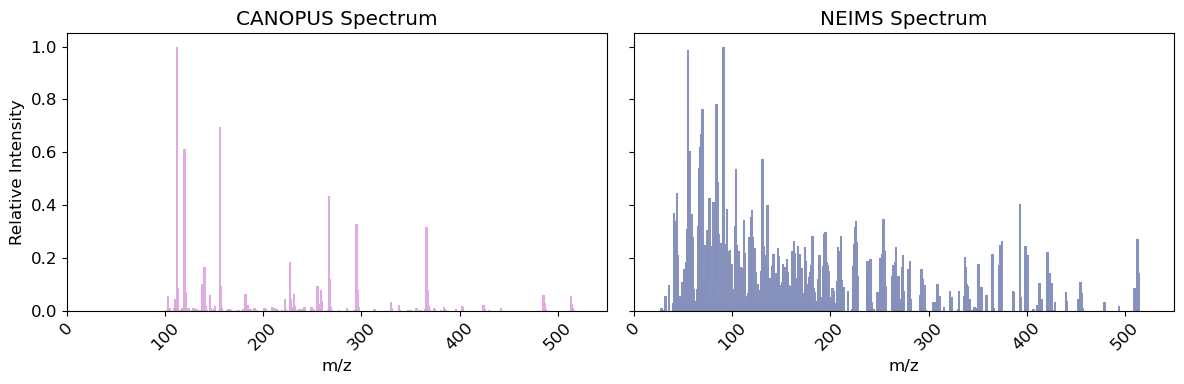

In [154]:
# Normalize intensities for easier comparison (optional but helpful)
ints_norm = ints / ints.max()
ints_neims_norm = ints_neims / ints_neims.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Plot CANOPUS spectrum
ax1.bar(locs, ints_norm, width=2.5, color='#e1aee4', edgecolor = 'black', linewidth=0.01)
ax1.set_title("CANOPUS Spectrum")
ax1.set_xlabel("m/z")
ax1.set_ylabel("Relative Intensity")
ax1.set_xlim(0, 550)
ax1.tick_params(axis='x', rotation=45)

# Plot NEIMS spectrum
ax2.bar(locs_neims, ints_neims_norm, width=2.5, color='#8995BF', edgecolor = 'black', linewidth=0.01)
ax2.set_title("NEIMS Spectrum")
ax2.set_xlabel("m/z")
ax2.set_xlim(0, 550)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('spec.png', dpi=300)
plt.show()

In [150]:
mol = MolFromSmiles('CCC(=O)CCCCCC1C(=O)NC(C(=O)NC(C(=O)N2CCCCC2C(=O)N1)CC3=CC=CC=C3)C')
# Save to file
Draw.MolToFile(mol, 'molecule.png', size=(400, 400))

In [152]:
drawer = Draw.MolDraw2DSVG(1000, 1000)
drawer.drawOptions().transparentBackground = True
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

# Save as SVG
with open("molecule.svg", "w") as f:
    f.write(drawer.GetDrawingText())

In [155]:
# Set up drawer with larger canvas
drawer = Draw.MolDraw2DSVG(1000, 1000)
opts = drawer.drawOptions()

# Increase font size and line width
opts.atomLabelFontSize = 1.8  # Default is 0.8–1.0
opts.bondLineWidth = 3.0      # Default is ~1.5
opts.transparentBackground = True

# Draw and save
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

with open("molecule_large.svg", "w") as f:
    f.write(drawer.GetDrawingText())

ArgumentError: Python argument types in
    None.None(MolDrawOptions, float)
did not match C++ signature:
    None(RDKit::MolDrawOptions {lvalue}, int)